# Layer 1: Marketplace Health Dashboard (이상이 있나?)

## Why This Analysis Matters
In a two-sided marketplace, problems on either side propagate quickly to the other.
A sudden GMV drop could mean seller churn, buyer drop-off, or operational collapse —
but without a health dashboard you can't tell which.

This notebook answers: **Is anything abnormal right now?**

**Metrics:**
- Monthly GMV trend with statistical anomaly flags (rolling z-score)
- Active seller count vs. active buyer count over time
- Transaction completion rate trend
- Supply/demand balance by category (orders per active seller)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

orders = pd.read_csv('../data/olist_orders_dataset.csv',
    parse_dates=['order_purchase_timestamp','order_approved_at',
                 'order_delivered_carrier_date','order_delivered_customer_date',
                 'order_estimated_delivery_date'])
order_items   = pd.read_csv('../data/olist_order_items_dataset.csv')
customers     = pd.read_csv('../data/olist_customers_dataset.csv')
products      = pd.read_csv('../data/olist_products_dataset.csv')
category_trans= pd.read_csv('../data/product_category_name_translation.csv')

print(f"Orders: {len(orders):,}  Items: {len(order_items):,}  "
      f"Customers: {len(customers):,}")


Orders: 99,441  Items: 112,650  Customers: 99,441


## 1. Monthly GMV Trend with Anomaly Detection

**Definition:** GMV = sum of item prices on delivered orders, aggregated monthly.

**Anomaly rule:** Flag any month where the 3-month rolling z-score |z| > 2.
This catches sudden drops or spikes that deviate more than 2 standard deviations
from the recent trend — a standard threshold for operational alerts.


In [2]:
orders_items = orders.merge(
    order_items[['order_id','price','seller_id']], on='order_id')
orders_items['month'] = (orders_items['order_purchase_timestamp']
                         .dt.to_period('M').dt.to_timestamp())

gmv_monthly = (orders_items[orders_items['order_status'] == 'delivered']
               .groupby('month')['price'].sum()
               .reset_index(name='gmv'))
# Trim first/last months (partial data)
gmv_monthly = gmv_monthly.iloc[1:-1].copy().reset_index(drop=True)

# Rolling z-score (window = 3)
W = 3
gmv_monthly['roll_mean'] = gmv_monthly['gmv'].rolling(W, center=True, min_periods=2).mean()
gmv_monthly['roll_std']  = gmv_monthly['gmv'].rolling(W, center=True, min_periods=2).std()
gmv_monthly['z_score']   = ((gmv_monthly['gmv'] - gmv_monthly['roll_mean'])
                             / gmv_monthly['roll_std'])
gmv_monthly['anomaly']   = gmv_monthly['z_score'].abs() > 2

print(gmv_monthly[['month','gmv','z_score','anomaly']].to_string(index=False))


     month       gmv   z_score  anomaly
2016-10-01  40325.11  0.707107    False
2016-12-01     10.90 -0.895566    False
2017-01-01 111798.36 -0.030269    False
2017-02-01 234223.40 -0.006872    False
2017-03-01 359198.85  0.709242    False
2017-04-01 340669.68 -0.687917    False
2017-05-01 489338.25  0.967575    False
2017-06-01 421923.37 -1.148340    False
2017-07-01 481604.52 -0.067237    False
2017-08-01 554699.70  0.107616    False
2017-09-01 607399.67  0.084238    False
2017-10-01 648247.65 -0.476772    False
2017-11-01 987765.37  1.126759    False
2017-12-01 726033.19 -1.123453    False
2018-01-01 924645.00  0.996294    False
2018-02-01 826437.13 -1.127520    False
2018-03-01 953356.25  0.446192    False
2018-04-01 973534.09  0.415712    False
2018-05-01 977544.69  0.606169    False
2018-06-01 856077.86 -0.663747    False
2018-07-01 867953.46  0.707107    False


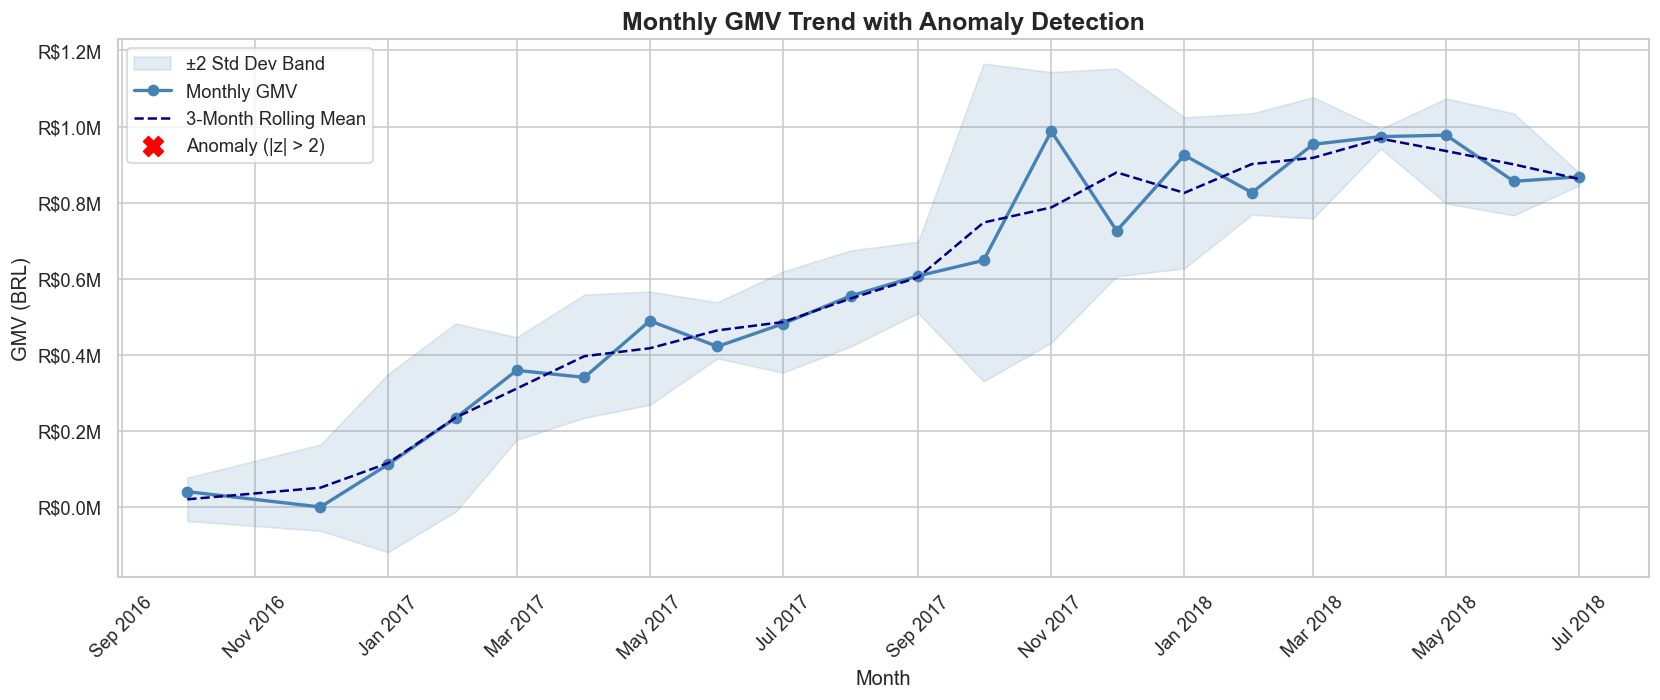

In [3]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.fill_between(gmv_monthly['month'],
    gmv_monthly['roll_mean'] - 2 * gmv_monthly['roll_std'],
    gmv_monthly['roll_mean'] + 2 * gmv_monthly['roll_std'],
    alpha=0.15, color='steelblue', label='±2 Std Dev Band')

ax.plot(gmv_monthly['month'], gmv_monthly['gmv'],
        marker='o', color='steelblue', linewidth=2, label='Monthly GMV')
ax.plot(gmv_monthly['month'], gmv_monthly['roll_mean'],
        color='navy', linestyle='--', linewidth=1.5, label='3-Month Rolling Mean')

anomalies = gmv_monthly[gmv_monthly['anomaly']]
ax.scatter(anomalies['month'], anomalies['gmv'],
           color='red', zorder=5, s=140, marker='X', label='Anomaly (|z| > 2)')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'R${x/1e6:.1f}M'))
ax.set_title('Monthly GMV Trend with Anomaly Detection', fontsize=15, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('GMV (BRL)')
ax.legend()
plt.tight_layout()
plt.savefig('../images/gmv_anomaly.png', dpi=150, bbox_inches='tight')
plt.show()


## 2. Active Sellers vs. Active Buyers Over Time

**Active buyer:** customer with ≥1 order placed in that month.
**Active seller:** seller with ≥1 item sold in that month.

The buyer-to-seller ratio is a proxy for **demand intensity** — how hard each seller is
working to meet demand. Ratio rising rapidly = demand outpacing supply → opportunity
to onboard new sellers. Ratio falling = supply surplus → focus on demand stimulation.


In [4]:
orders_cust = orders.merge(
    customers[['customer_id','customer_unique_id']], on='customer_id')
orders_cust['month'] = (orders_cust['order_purchase_timestamp']
                        .dt.to_period('M').dt.to_timestamp())

active_buyers = (orders_cust.groupby('month')['customer_unique_id']
                 .nunique().reset_index(name='active_buyers'))

orders_sellers = orders.merge(
    order_items[['order_id','seller_id']], on='order_id')
orders_sellers['month'] = (orders_sellers['order_purchase_timestamp']
                            .dt.to_period('M').dt.to_timestamp())

active_sellers = (orders_sellers.groupby('month')['seller_id']
                  .nunique().reset_index(name='active_sellers'))

sd = (active_buyers.merge(active_sellers, on='month')
                   .iloc[1:-1].reset_index(drop=True))
sd['buyer_to_seller_ratio'] = sd['active_buyers'] / sd['active_sellers']
print(sd.to_string(index=False))


     month  active_buyers  active_sellers  buyer_to_seller_ratio
2016-10-01            321             143               2.244755
2016-12-01              1               1               1.000000
2017-01-01            765             227               3.370044
2017-02-01           1755             427               4.110070
2017-03-01           2642             499               5.294589
2017-04-01           2372             506               4.687747
2017-05-01           3625             583               6.217839
2017-06-01           3180             539               5.899814
2017-07-01           3947             606               6.513201
2017-08-01           4246             708               5.997175
2017-09-01           4212             731               5.761970
2017-10-01           4561             776               5.877577
2017-11-01           7430             965               7.699482
2017-12-01           5603             861               6.507549
2018-01-01           7166

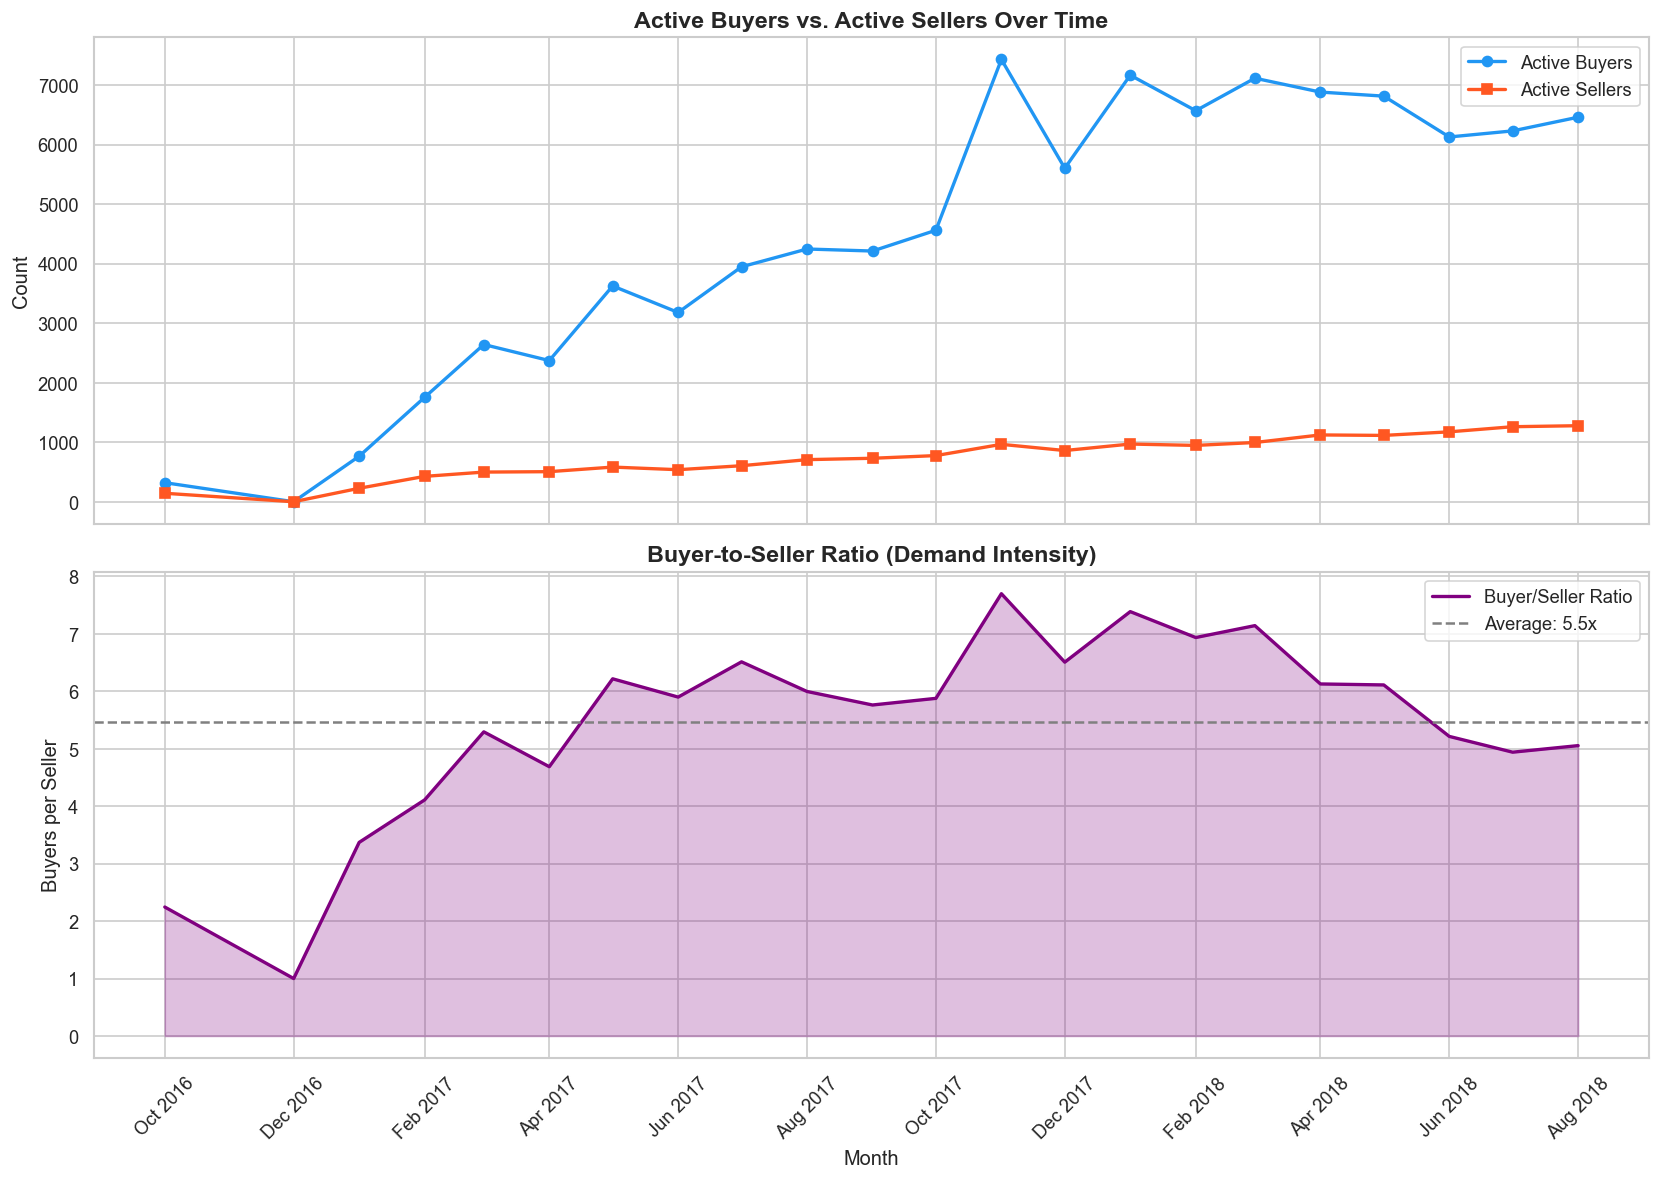

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

axes[0].plot(sd['month'], sd['active_buyers'],
             color='#2196F3', marker='o', linewidth=2, label='Active Buyers')
axes[0].plot(sd['month'], sd['active_sellers'],
             color='#FF5722', marker='s', linewidth=2, label='Active Sellers')
axes[0].set_title('Active Buyers vs. Active Sellers Over Time',
                  fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].fill_between(sd['month'], sd['buyer_to_seller_ratio'],
                     alpha=0.25, color='purple')
axes[1].plot(sd['month'], sd['buyer_to_seller_ratio'],
             color='purple', linewidth=2, label='Buyer/Seller Ratio')
avg_ratio = sd['buyer_to_seller_ratio'].mean()
axes[1].axhline(avg_ratio, linestyle='--', color='gray',
                label=f'Average: {avg_ratio:.1f}x')
axes[1].set_title('Buyer-to-Seller Ratio (Demand Intensity)',
                  fontsize=14, fontweight='bold')
axes[1].set_ylabel('Buyers per Seller')
axes[1].set_xlabel('Month')
axes[1].legend()

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig('../images/supply_demand_balance.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. Transaction Completion Rate Trend

**Completion rate** = delivered orders / all orders placed that month.
This is a core operational health metric. A declining trend signals:
- Seller-side: increasing cancellations or shipping failures
- Logistics: carrier breakdowns
- Fraud: more fraudulent orders being placed and later voided

Target threshold: >90% is considered healthy for most marketplaces.


In [6]:
orders['month'] = (orders['order_purchase_timestamp']
                   .dt.to_period('M').dt.to_timestamp())

def status_agg(g):
    return pd.Series({
        'total_orders': len(g),
        'delivered':    (g['order_status'] == 'delivered').sum(),
        'canceled':     (g['order_status'] == 'canceled').sum(),
    })

completion = (orders.groupby('month').apply(status_agg)
              .reset_index().iloc[1:-1].reset_index(drop=True))

completion['completion_rate'] = completion['delivered'] / completion['total_orders']
completion['cancel_rate']     = completion['canceled']  / completion['total_orders']
completion['completion_roll'] = (completion['completion_rate']
                                  .rolling(3, center=True, min_periods=2).mean())
print(completion[['month','total_orders','delivered',
                   'completion_rate','cancel_rate']].to_string(index=False))


     month  total_orders  delivered  completion_rate  cancel_rate
2016-10-01           324        265         0.817901     0.074074
2016-12-01             1          1         1.000000     0.000000
2017-01-01           800        750         0.937500     0.003750
2017-02-01          1780       1653         0.928652     0.009551
2017-03-01          2682       2546         0.949292     0.012304
2017-04-01          2404       2303         0.957987     0.007488
2017-05-01          3700       3546         0.958378     0.007838
2017-06-01          3245       3135         0.966102     0.004931
2017-07-01          4026       3872         0.961749     0.006955
2017-08-01          4331       4193         0.968137     0.006234
2017-09-01          4285       4150         0.968495     0.004667
2017-10-01          4631       4478         0.966962     0.005614
2017-11-01          7544       7289         0.966198     0.004905
2017-12-01          5673       5513         0.971796     0.001939
2018-01-01

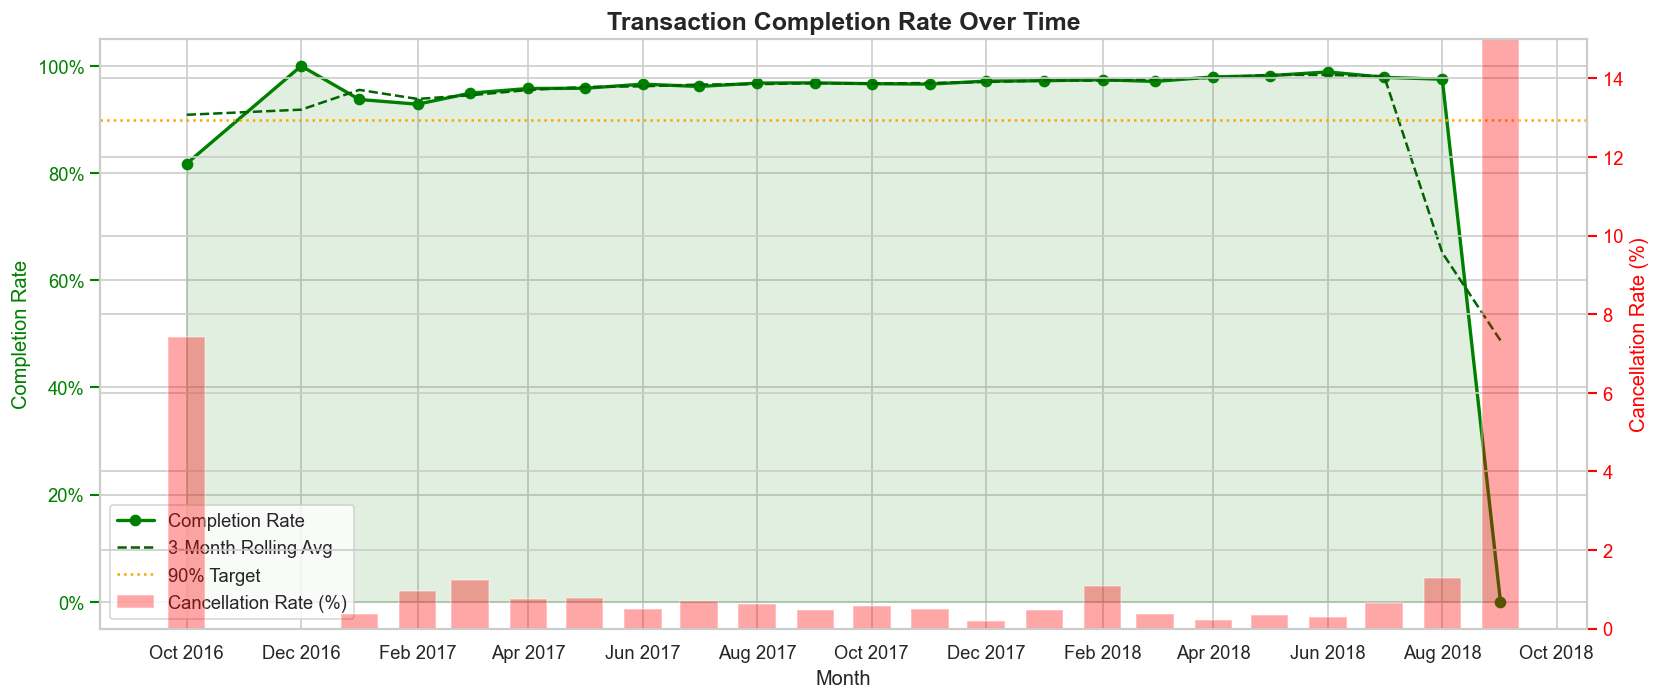

In [7]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.fill_between(completion['month'], completion['completion_rate'],
                alpha=0.12, color='green')
ax.plot(completion['month'], completion['completion_rate'],
        color='green', marker='o', linewidth=2, label='Completion Rate')
ax.plot(completion['month'], completion['completion_roll'],
        color='darkgreen', linestyle='--', linewidth=1.5,
        label='3-Month Rolling Avg')

ax2 = ax.twinx()
ax2.bar(completion['month'], completion['cancel_rate'] * 100,
        width=20, alpha=0.35, color='red', label='Cancellation Rate (%)')
ax2.set_ylabel('Cancellation Rate (%)', color='red')
ax2.tick_params(axis='y', colors='red')
ax2.set_ylim(0, 15)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.set_title('Transaction Completion Rate Over Time', fontsize=15, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Completion Rate', color='green')
ax.tick_params(axis='y', colors='green')
ax.axhline(0.9, linestyle=':', color='orange', linewidth=1.5, label='90% Target')

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='lower left')

plt.tight_layout()
plt.savefig('../images/completion_rate.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Supply/Demand Ratio by Category

**Supply/demand ratio** = orders per active seller per month within a category.

- **High ratio (>10):** demand-constrained — few sellers competing for many orders.
  *Action: aggressive seller acquisition in this category.*
- **Low ratio (<3):** supply-saturated — many sellers chasing few orders.
  *Action: stimulate demand (promotions, marketing) or let over-supply self-correct.*


In [8]:
items_cat = (order_items
    .merge(products[['product_id','product_category_name']], on='product_id')
    .merge(category_trans, on='product_category_name', how='left'))
items_cat['category'] = (items_cat['product_category_name_english']
                         .fillna(items_cat['product_category_name']))

items_orders = items_cat.merge(
    orders[['order_id','order_purchase_timestamp','order_status']], on='order_id')
items_orders['month'] = (items_orders['order_purchase_timestamp']
                          .dt.to_period('M').dt.to_timestamp())

top_cats = items_cat['category'].value_counts().head(10).index.tolist()
filtered = (items_orders[(items_orders['category'].isin(top_cats)) &
                         (items_orders['order_status'] == 'delivered')])

cat_monthly = (filtered.groupby(['month','category'])
    .agg(demand=('order_id','nunique'), supply=('seller_id','nunique'))
    .reset_index())
cat_monthly = (cat_monthly[
    (cat_monthly['month'] > cat_monthly['month'].min()) &
    (cat_monthly['month'] < cat_monthly['month'].max())])
cat_monthly['orders_per_seller'] = cat_monthly['demand'] / cat_monthly['supply']

print("Average orders/seller by category:")
print(cat_monthly.groupby('category')['orders_per_seller']
      .mean().sort_values(ascending=False).round(2).to_string())


Average orders/seller by category:
category
watches_gifts            10.33
bed_bath_table            9.03
telephony                 6.39
computers_accessories     4.64
garden_tools              4.22
health_beauty             4.14
furniture_decor           3.77
sports_leisure            3.30
housewares                3.07
auto                      2.83


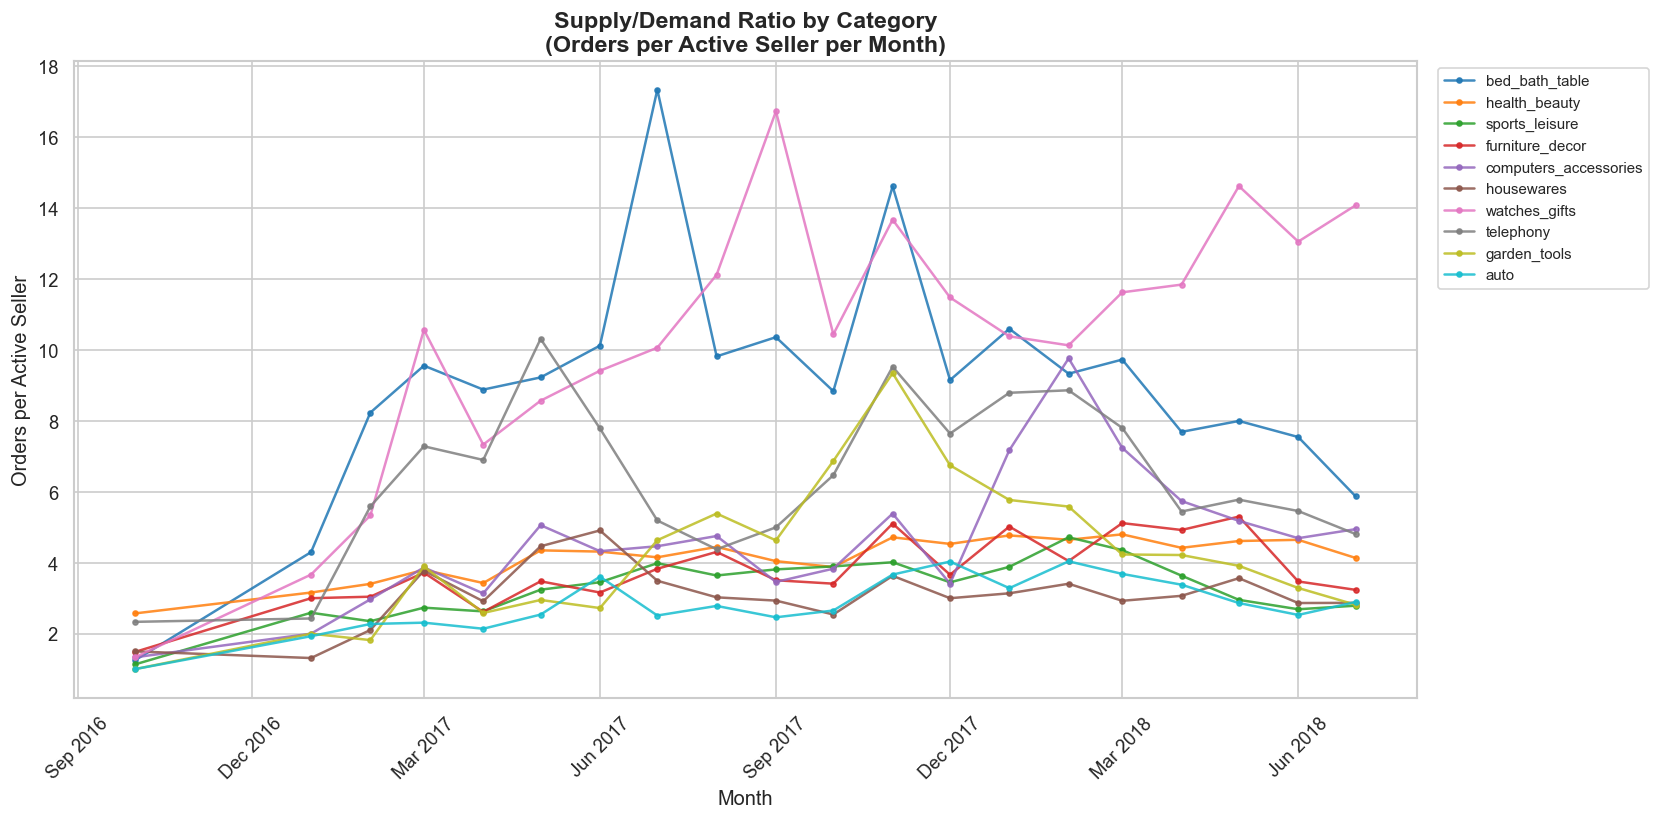

In [9]:
fig, ax = plt.subplots(figsize=(14, 7))
colors = plt.cm.tab10.colors

for i, cat in enumerate(top_cats):
    sub = cat_monthly[cat_monthly['category'] == cat]
    ax.plot(sub['month'], sub['orders_per_seller'],
            marker='.', linewidth=1.5, alpha=0.85, color=colors[i], label=cat)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
ax.set_title('Supply/Demand Ratio by Category\n(Orders per Active Seller per Month)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Orders per Active Seller')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('../images/supply_demand_by_category.png', dpi=150, bbox_inches='tight')
plt.show()


## Layer 1 Health Summary

| Metric | Query | Alert Threshold |
|--------|-------|-----------------|
| GMV | Sum of item prices on delivered orders | Monthly z-score \|z\| > 2 |
| Active Buyers | Unique `customer_unique_id` per month | MoM drop > 15% |
| Active Sellers | Unique `seller_id` per month | MoM drop > 10% |
| Buyer/Seller Ratio | active_buyers / active_sellers | Sustained rise > 20% above avg |
| Completion Rate | delivered / total orders | Falls below 90% |
| Orders/Seller | orders ÷ active sellers per category | Category drops below 3 or spikes above 15 |

→ **Drill down into any flagged metric using `02_drilldown_analysis.ipynb`.**
